# FinCast — Dataset Analysis
Produces charts, tables, and CSVs for human review and LLM/agent consumption.

In [13]:
import os, json, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

DATA_DIR     = '../data/raw'
CONFIG_PATH  = '../create_data/gdelt_config.yaml'
ANALYSIS_DIR = 'analysis'
os.makedirs(ANALYSIS_DIR, exist_ok=True)

def save_csv(df, name):
    path = os.path.join(ANALYSIS_DIR, name)
    df.to_csv(path)
    print(f'  Saved: {path}')

print('Libraries loaded')

Libraries loaded


In [14]:
with open(CONFIG_PATH, 'r') as fh:
    cfg = yaml.safe_load(fh)
t = cfg.get('tickers', {})
ALL_TICKERS = {}
ALL_TICKERS.update({k: v for k, v in (t.get('company_queries', {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('plain_names',    {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('sector_queries', {}) or {}).items() if v})
BENCHMARKS      = t.get('benchmarks', {})
COMPANY_QUERIES = set((t.get('company_queries', {}) or {}).keys()) | \
                  set((t.get('plain_names',    {}) or {}).keys())
ETF_LABELS = {
    'SOXX':'Semiconductor','SKYY':'Cloud','DRIV':'EV','XLV':'Healthcare',
    'XLF':'Finance','BOTZ':'AI/Robotics','USO':'Oil','TLT':'Bonds',
    'UUP':'Dollar','XLK':'Tech ETF','CIBR':'Cybersec','SPY':'S&P500','QQQ':'Nasdaq'
}
print(f'Loaded {len(ALL_TICKERS)} ticker mappings')

Loaded 35 ticker mappings


In [15]:
def load_articles(data_dir):
    rows = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if not f.endswith('.json'): continue
            with open(os.path.join(root, f), 'r', encoding='utf-8') as fh:
                meta = json.load(fh)
            gdelt_query = meta.get('gdelt_query', '')
            ticker      = ALL_TICKERS.get(gdelt_query)
            if not ticker: continue
            pc           = meta.get('price_changes', {})
            ticker_pc    = pc.get(gdelt_query, {})
            benchmark    = BENCHMARKS.get(ticker, 'SPY')
            benchmark_pc = pc.get(benchmark, {})
            date_str     = (meta.get('publish_date') or meta.get('scrape_date',''))[:10]
            rows.append({
                'date':            pd.to_datetime(date_str, errors='coerce'),
                'site':            meta.get('site',''),
                'gdelt_query':     gdelt_query,
                'ticker':          ticker,
                'benchmark':       benchmark,
                'category':        'company' if gdelt_query in COMPANY_QUERIES else 'sector/macro',
                'title':           meta.get('title',''),
                'summary':         meta.get('summary',''),
                'sentiment':       meta.get('sentiment'),
                'word_count':      meta.get('word_count', 0),
                'relevance':       meta.get('relevance', 1),
                'direction':       meta.get('direction', ''),
                'base_price':      ticker_pc.get('base_price'),
                'next_price':      ticker_pc.get('next_price'),
                'change_1d':       ticker_pc.get('change_1d'),
                'bucket_1d':       ticker_pc.get('bucket_1d'),
                'magnitude':       ticker_pc.get('magnitude'),
                'bm_change_1d':    benchmark_pc.get('change_1d'),
                'bm_bucket_1d':    benchmark_pc.get('bucket_1d'),
                'url':             meta.get('url',''),
            })
    return pd.DataFrame(rows)

df = load_articles(DATA_DIR).sort_values('date').reset_index(drop=True)
# Filter out low-relevance articles to focus on more impactful news
df = df[df['relevance'] > 1]
print(f'Loaded {len(df):,} articles')
print(f'Date range:      {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Unique tickers:  {df["ticker"].nunique()}')
print(f'With price data: {df["bucket_1d"].notna().sum():,}')

Loaded 1,897 articles
Date range:      2026-03-14 to 2026-04-15
Unique tickers:  20
With price data: 1,732


## 1 — Article & Ticker Distribution

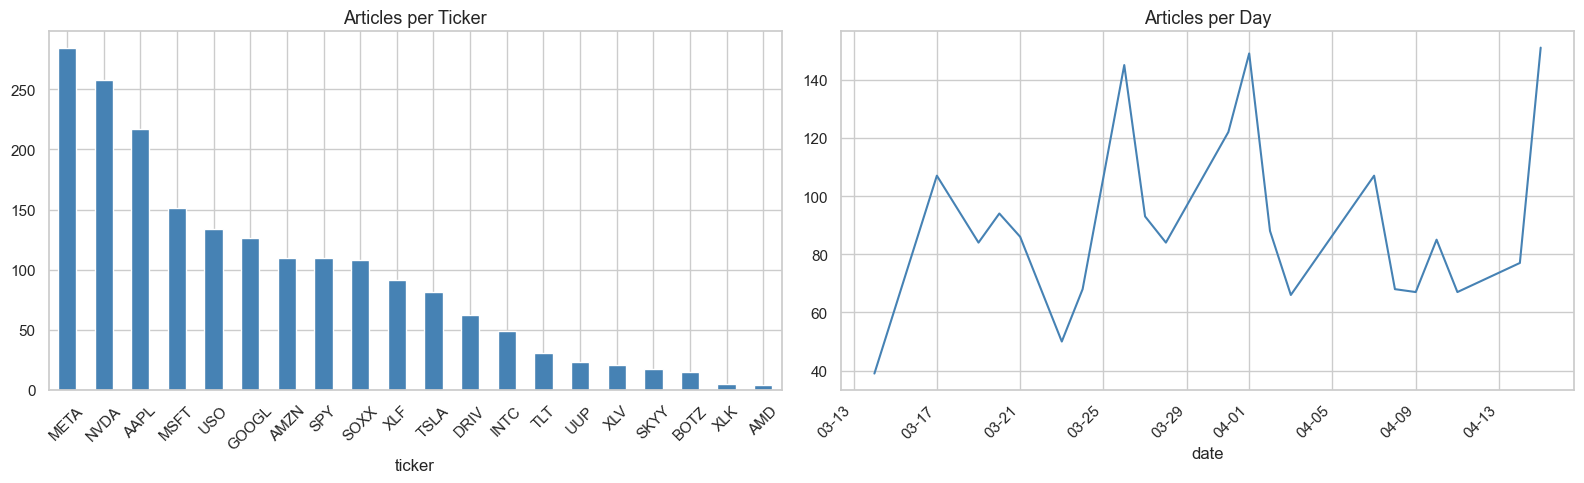

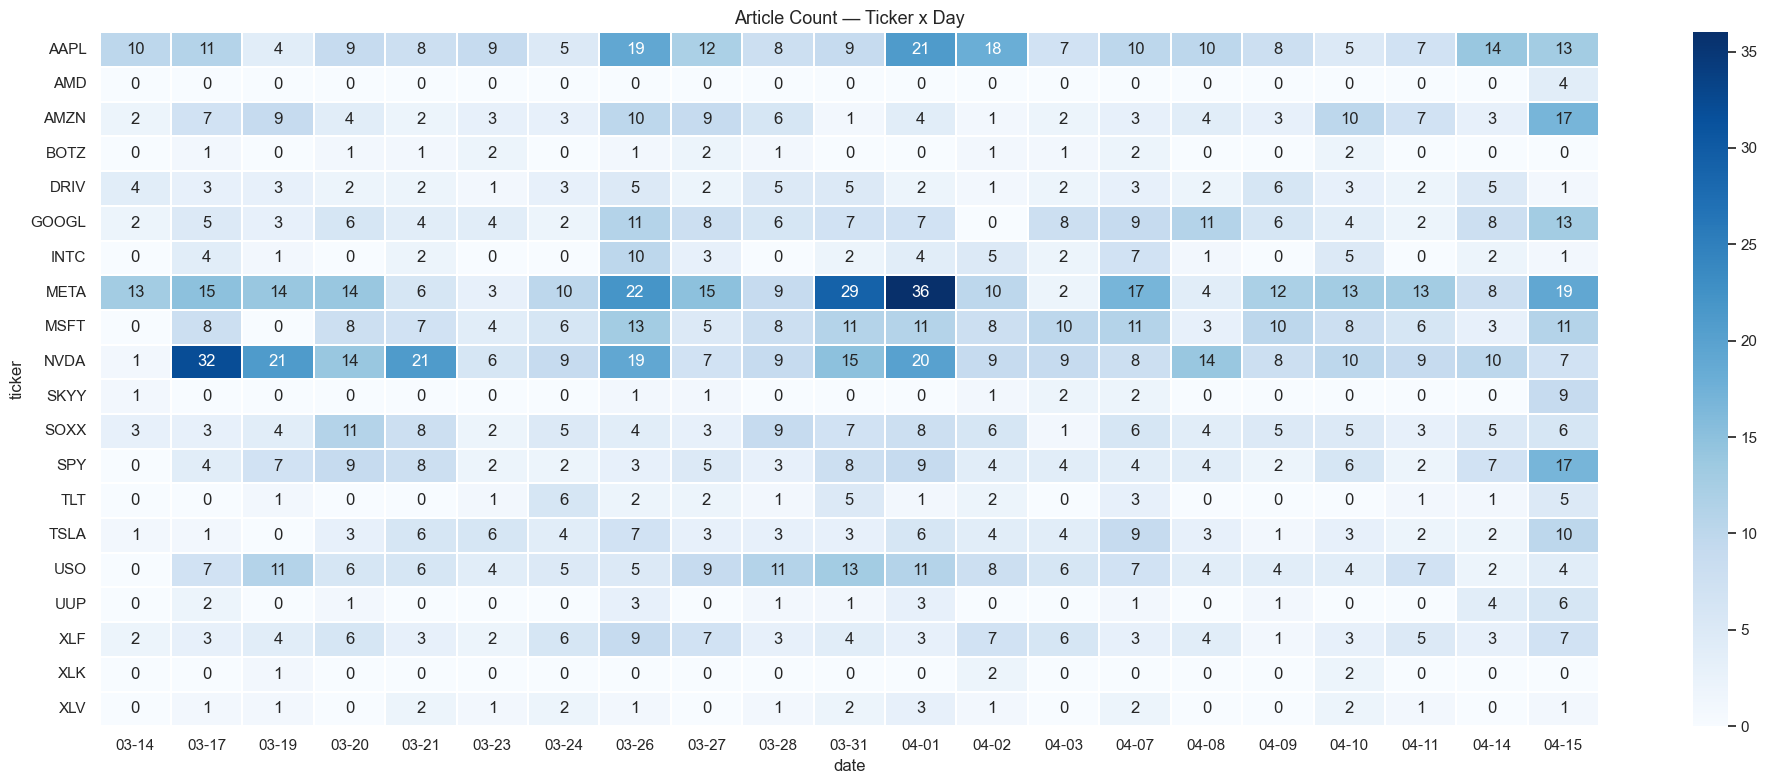


--- Articles per Ticker ---


,count,pct
ticker,,
META,284,15.0
NVDA,258,13.6
AAPL,217,11.4
MSFT,151,8.0
USO,134,7.1
GOOGL,126,6.6
AMZN,110,5.8
SPY,110,5.8
SOXX,108,5.7


  Saved: analysis\dist_articles_per_ticker.csv

--- Articles per Day ---


,count
date,
2026-03-14,39
2026-03-17,107
2026-03-19,84
2026-03-20,94
2026-03-21,86
2026-03-23,50
2026-03-24,68
2026-03-26,145
2026-03-27,93


  Saved: analysis\dist_articles_per_day.csv
  Saved: analysis\dist_ticker_day_heatmap.csv


In [16]:
# Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ticker_counts = df['ticker'].value_counts()
ticker_counts.plot(kind='bar', ax=axes[0], color='steelblue',)
axes[0].set_title('Articles per Ticker')
axes[0].tick_params(axis='x', rotation=45)
daily = df.groupby('date').size()
daily.plot(ax=axes[1], color='steelblue', linewidth=1.5)
axes[1].set_title('Articles per Day')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()

pivot = df.pivot_table(index='ticker', columns=df['date'].dt.strftime('%m-%d'),
                       values='url', aggfunc='count', fill_value=0)
plt.figure(figsize=(20, 8))
sns.heatmap(pivot, cmap='Blues', linewidths=0.3, annot=True, fmt='d')
plt.title('Article Count — Ticker x Day')
plt.tight_layout(); plt.show()

# Tables
ticker_table = ticker_counts.rename('count').to_frame()
ticker_table['pct'] = (ticker_table['count'] / len(df) * 100).round(1)
print('\n--- Articles per Ticker ---')
display(ticker_table)
save_csv(ticker_table, 'dist_articles_per_ticker.csv')

daily_table = daily.rename('count').to_frame()
daily_table.index = daily_table.index.strftime('%Y-%m-%d')
print('\n--- Articles per Day ---')
display(daily_table)
save_csv(daily_table, 'dist_articles_per_day.csv')
save_csv(pivot, 'dist_ticker_day_heatmap.csv')

## 2 — Sentiment Distribution

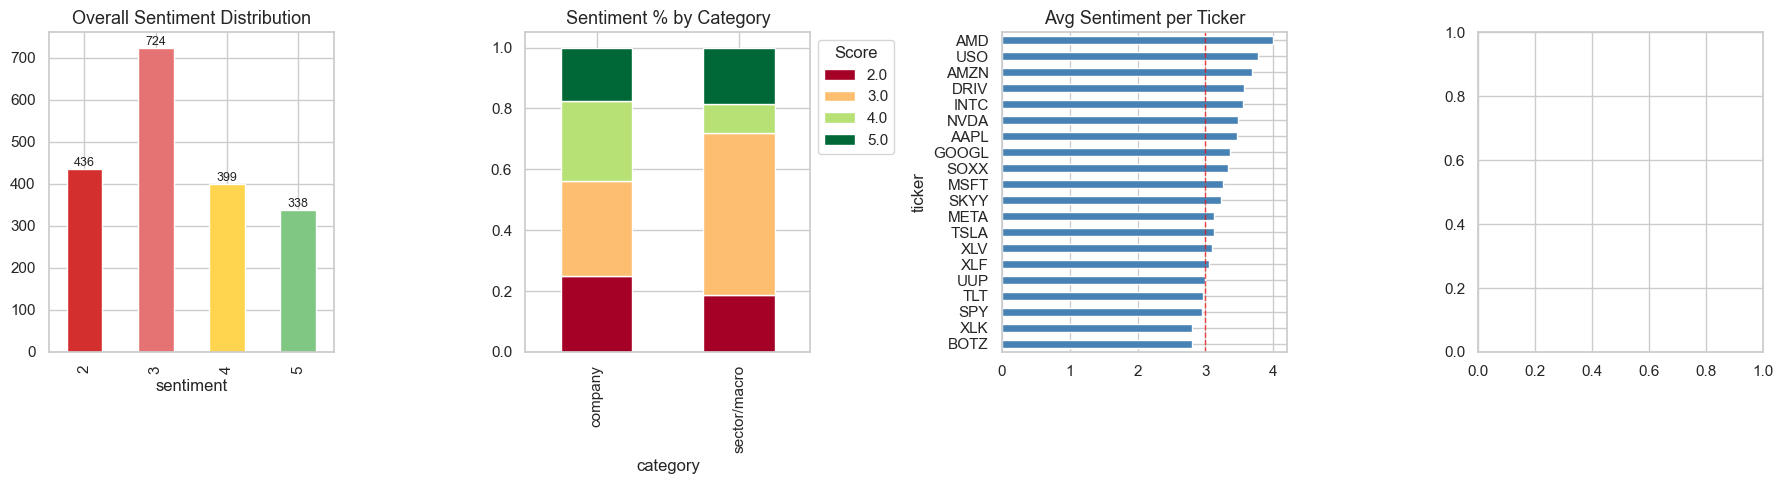

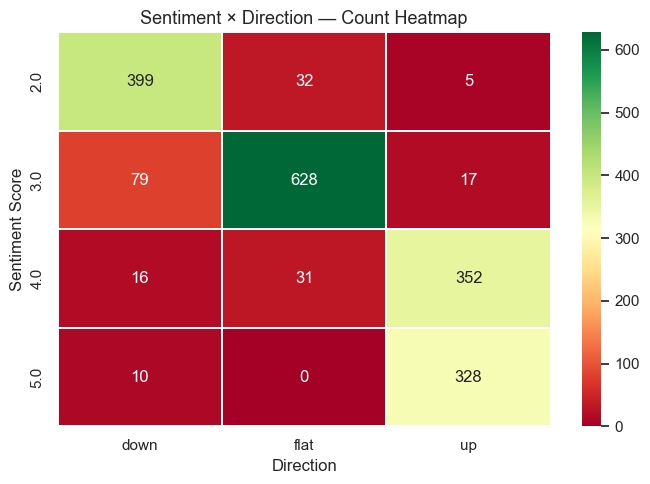


--- Sentiment Distribution ---


,count,pct
sentiment_score,,
2,436,23.0
3,724,38.2
4,399,21.0
5,338,17.8


  Saved: analysis\dist_sentiment.csv

--- Sentiment Stats per Ticker ---


,count,mean,std,min,max
ticker,,,,,
AAPL,217,3.47,1.05,2.0,5.0
AMD,4,4.00,0.00,4.0,4.0
AMZN,110,3.69,0.97,2.0,5.0
BOTZ,15,2.80,0.56,2.0,4.0
DRIV,62,3.56,1.13,2.0,5.0
GOOGL,126,3.36,1.01,2.0,5.0
INTC,49,3.55,1.06,2.0,5.0
META,284,3.13,1.06,2.0,5.0
MSFT,151,3.26,0.80,2.0,5.0


  Saved: analysis\dist_sentiment_per_ticker.csv


In [17]:
colors = ['#d32f2f','#e57373','#ffd54f','#81c784','#2e7d32']
sent   = df['sentiment'].dropna().astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sent.plot(kind='bar', ax=axes[0], color=colors)
# sentiment distribution (count)
axes[0].set_title('Overall Sentiment Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
df.dropna(subset=['sentiment']).groupby('category')['sentiment'] \
  .value_counts(normalize=True).unstack() \
  .plot(kind='bar', ax=axes[1], colormap='RdYlGn', stacked=True)

axes[1].set_title('Sentiment % by Category')
axes[1].legend(title='Score', bbox_to_anchor=(1,1))
df.groupby('ticker')['sentiment'].mean().sort_values() \
  .plot(kind='barh', ax=axes[2], color='steelblue')

axes[2].axvline(3, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Avg Sentiment per Ticker')
plt.tight_layout(); plt.show()

# Sentiment × Direction heatmap
axes[3].set_title('Sentiment × Direction Distribution')
sent_dir = (
    df.dropna(subset=['sentiment', 'direction'])
      .groupby(['sentiment', 'direction'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(7, 5))
sns.heatmap(sent_dir, annot=True, fmt='d', cmap='RdYlGn', linewidths=0.3)
plt.title('Sentiment × Direction — Count Heatmap')
plt.xlabel('Direction')
plt.ylabel('Sentiment Score')
plt.tight_layout()
plt.show()

# Tables
sent_table = pd.DataFrame({'count': sent, 'pct': (sent/sent.sum()*100).round(1)})
sent_table.index.name = 'sentiment_score'
print('\n--- Sentiment Distribution ---')
display(sent_table)
save_csv(sent_table, 'dist_sentiment.csv')

sent_ticker = df.dropna(subset=['sentiment']).groupby('ticker')['sentiment'].agg(
    count='count', mean='mean', std='std', min='min', max='max').round(2)
print('\n--- Sentiment Stats per Ticker ---')
display(sent_ticker)
save_csv(sent_ticker, 'dist_sentiment_per_ticker.csv')

flat_pct = sent.get(3,0)/sent.sum()*100
if flat_pct > 50:
    print(f'\n⚠ Neutral sentiment (3) = {flat_pct:.1f}% — consider more targeted queries')

## 3 — Price Bucket Distribution

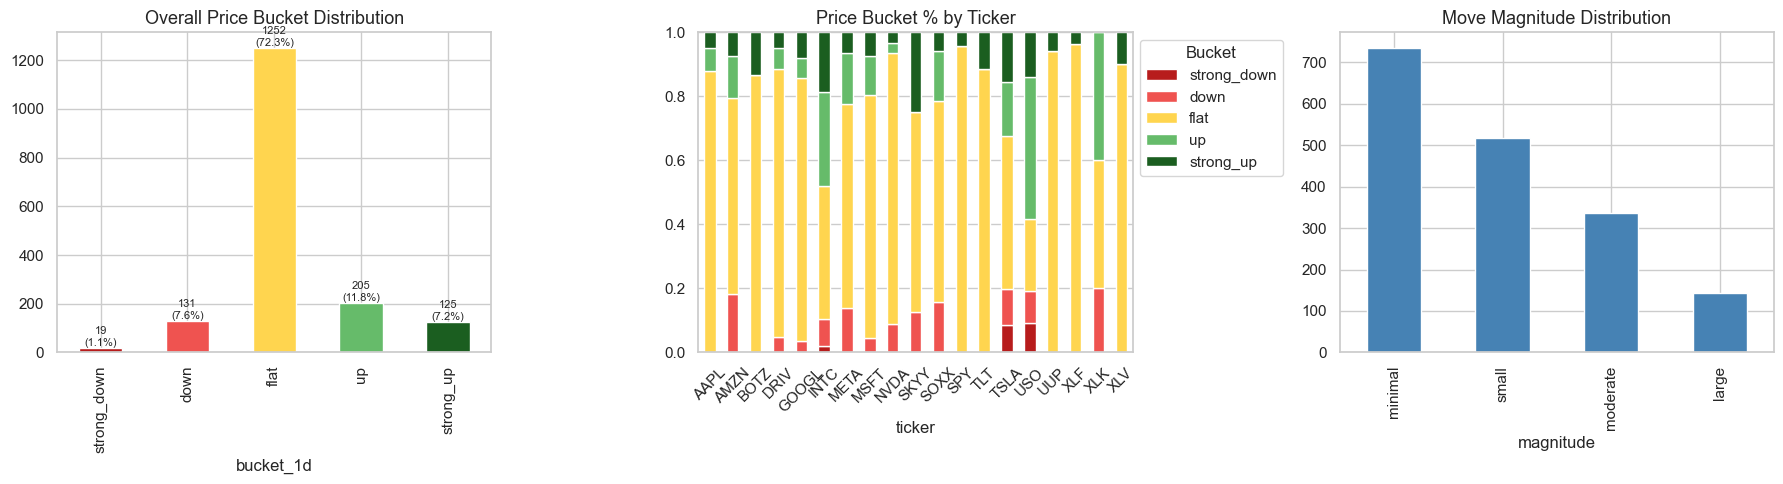


--- Price Bucket Distribution ---


,count,pct
bucket_1d,,
strong_down,19,1.1
down,131,7.6
flat,1252,72.3
up,205,11.8
strong_up,125,7.2


  Saved: analysis\dist_price_buckets.csv

--- Price Bucket % per Ticker ---


,strong_down_pct,down_pct,flat_pct,up_pct,strong_up_pct,flat_flag
ticker,,,,,,
AAPL,NaN,NaN,88.1,7.0,5.0,HIGH
AMZN,NaN,18.3,61.3,12.9,7.5,OK
BOTZ,NaN,NaN,86.7,NaN,13.3,HIGH
DRIV,NaN,4.9,83.6,6.6,4.9,HIGH
GOOGL,NaN,3.6,82.1,6.2,8.0,HIGH
INTC,2.1,8.3,41.7,29.2,18.8,OK
META,NaN,14.0,63.6,15.9,6.6,OK
MSFT,NaN,4.4,75.9,12.4,7.3,HIGH
NVDA,NaN,8.8,84.9,3.2,3.2,HIGH


  Saved: analysis\dist_price_buckets_per_ticker.csv

--- Magnitude Distribution ---


,count,pct
magnitude,,
minimal,735,42.4
small,517,29.8
moderate,336,19.4
large,144,8.3


  Saved: analysis\dist_magnitude.csv


In [18]:
labeled       = df.dropna(subset=['bucket_1d'])
bucket_order  = ['strong_down','down','flat','up','strong_up']
colors_bucket = ['#b71c1c','#ef5350','#ffd54f','#66bb6a','#1b5e20']
bucket_counts = labeled['bucket_1d'].value_counts().reindex(bucket_order, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bucket_counts.plot(kind='bar', ax=axes[0], color=colors_bucket)
axes[0].set_title('Overall Price Bucket Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(labeled)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
labeled.groupby('ticker')['bucket_1d'].value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0) \
    .plot(kind='bar', stacked=True, ax=axes[1], color=colors_bucket)
axes[1].set_title('Price Bucket % by Ticker')
axes[1].legend(title='Bucket', bbox_to_anchor=(1,1))
axes[1].tick_params(axis='x', rotation=45)
mag_order = ['minimal','small','moderate','large']
labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0) \
    .plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Move Magnitude Distribution')
plt.tight_layout(); plt.show()

# Tables
bucket_table = pd.DataFrame({
    'count': bucket_counts,
    'pct':   (bucket_counts/bucket_counts.sum()*100).round(1)
})
print('\n--- Price Bucket Distribution ---')
display(bucket_table)
save_csv(bucket_table, 'dist_price_buckets.csv')

bucket_ticker = labeled.groupby('ticker')['bucket_1d'] \
    .value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0).mul(100).round(1)
bucket_ticker.columns = [f'{c}_pct' for c in bucket_ticker.columns]
bucket_ticker['flat_flag'] = bucket_ticker.get('flat_pct', pd.Series(dtype=float)).apply(
    lambda x: 'HIGH' if x > 70 else 'OK')
print('\n--- Price Bucket % per Ticker ---')
display(bucket_ticker)
save_csv(bucket_ticker, 'dist_price_buckets_per_ticker.csv')

mag_table = labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0)
mag_df = pd.DataFrame({'count': mag_table, 'pct': (mag_table/mag_table.sum()*100).round(1)})
print('\n--- Magnitude Distribution ---')
display(mag_df)
save_csv(mag_df, 'dist_magnitude.csv')

## 4 — Sentiment vs Price Mismatch

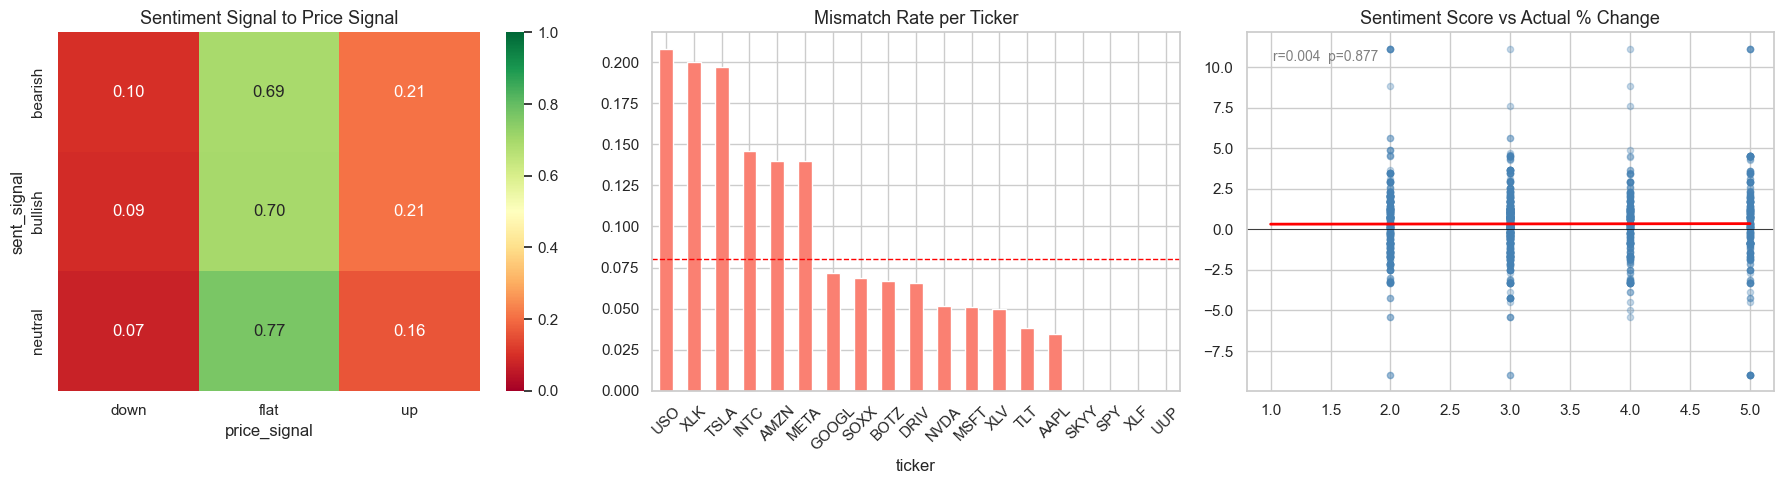


--- Confusion Matrix (counts) ---


price_signal,down,flat,up,Total
sent_signal,,,,
bearish,41,285,86,412
bullish,61,456,136,653
neutral,48,511,108,667
Total,150,1252,330,1732


  Saved: analysis\mismatch_confusion_matrix.csv

--- Mismatch Rate per Ticker ---


,mismatch_rate,mismatch_pct,flag
ticker,,,
USO,0.207692,20.8,OK
XLK,0.200000,20.0,OK
TSLA,0.197183,19.7,OK
INTC,0.145833,14.6,OK
AMZN,0.139785,14.0,OK
META,0.139535,14.0,OK
GOOGL,0.071429,7.1,OK
SOXX,0.068627,6.9,OK
BOTZ,0.066667,6.7,OK


  Saved: analysis\mismatch_rate_per_ticker.csv

Overall mismatch rate: 8.5%
Pearson r: 0.004  p=0.8770  not significant yet


In [19]:
labeled = df.dropna(subset=['sentiment','bucket_1d']).copy()
labeled['sentiment']    = labeled['sentiment'].astype(int)
labeled['sent_signal']  = labeled['sentiment'].apply(
    lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
labeled['price_signal'] = labeled['bucket_1d'].apply(
    lambda x: 'up' if x in ('up','strong_up') else ('down' if x in ('down','strong_down') else 'flat'))
labeled['mismatch']     = (
    ((labeled['sent_signal']=='bullish') & (labeled['price_signal']=='down')) |
    ((labeled['sent_signal']=='bearish') & (labeled['price_signal']=='up'))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = pd.crosstab(labeled['sent_signal'], labeled['price_signal'], normalize='index')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Sentiment Signal to Price Signal')
mismatch_rate = labeled.groupby('ticker')['mismatch'].mean().sort_values(ascending=False)
mismatch_rate.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].axhline(mismatch_rate.mean(), color='red', linestyle='--', linewidth=1)
axes[1].set_title('Mismatch Rate per Ticker')
axes[1].tick_params(axis='x', rotation=45)
sample = labeled.dropna(subset=['change_1d'])
axes[2].scatter(sample['sentiment'], sample['change_1d'], alpha=0.3, s=20, color='steelblue')
z = np.polyfit(sample['sentiment'], sample['change_1d'], 1)
xs = np.linspace(1, 5, 100)
axes[2].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.5)
r, p_val = stats.pearsonr(sample['sentiment'], sample['change_1d'])
axes[2].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                 xycoords='axes fraction', fontsize=10,
                 color='red' if p_val<0.05 else 'grey')
axes[2].set_title('Sentiment Score vs Actual % Change')
plt.tight_layout(); plt.show()

# Tables
cm_counts = pd.crosstab(labeled['sent_signal'], labeled['price_signal'],
                        margins=True, margins_name='Total')
print('\n--- Confusion Matrix (counts) ---')
display(cm_counts)
save_csv(cm_counts, 'mismatch_confusion_matrix.csv')

mismatch_table = mismatch_rate.rename('mismatch_rate').to_frame()
mismatch_table['mismatch_pct'] = (mismatch_table['mismatch_rate']*100).round(1)
mismatch_table['flag'] = mismatch_table['mismatch_rate'].apply(
    lambda x: 'HIGH' if x>0.4 else 'OK')
print('\n--- Mismatch Rate per Ticker ---')
display(mismatch_table)
save_csv(mismatch_table, 'mismatch_rate_per_ticker.csv')

print(f'\nOverall mismatch rate: {labeled["mismatch"].mean()*100:.1f}%')
print(f'Pearson r: {r:.3f}  p={p_val:.4f}  {"significant" if p_val<0.05 else "not significant yet"}')

## 5 — Edge Cases

In [20]:
mismatches  = labeled[labeled['mismatch']].copy()
edge_cols   = ['date','ticker','sentiment','sent_signal','bucket_1d',
                'price_signal','change_1d','magnitude','summary','url']
edge_table  = mismatches[edge_cols].copy()
edge_table['date'] = edge_table['date'].dt.strftime('%Y-%m-%d')

print(f'Total mismatches: {len(edge_table)}')
print('\n--- Bullish Sentiment but Price Dropped (worst 10) ---')
display(edge_table[edge_table['sent_signal']=='bullish'].sort_values('change_1d').head(10))
print('\n--- Bearish Sentiment but Price Rose (top 10) ---')
display(edge_table[edge_table['sent_signal']=='bearish'].sort_values('change_1d', ascending=False).head(10))
save_csv(edge_table.set_index('url'), 'edge_cases.csv')

Total mismatches: 147

--- Bullish Sentiment but Price Dropped (worst 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
735,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,Indonesia's free meals programme and rising gl...,https://www.straitstimes.com/asia/se-asia/to-f...
823,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,The Trump administration's waiver of sanctions...,https://www.straitstimes.com/world/middle-east...
848,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,United States Oil Fund shares surge as crude o...,https://www.benzinga.com/trading-ideas/movers/...
920,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,The rupee's depreciation due to rising crude o...,https://www.livemint.com/market/another-day-an...
972,2026-03-21,USO,5,bullish,strong_down,down,-8.9517,large,President Trump's criticism of NATO allies ove...,https://www.channelnewsasia.com/world/trump-na...
530,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,Crude oil prices surge due to attacks on energ...,https://www.livemint.com/economy/crude-oil-pri...
578,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,"Oil prices surge to $113.71 per barrel, signif...",https://fortune.com/article/price-of-oil-03-19...
533,2026-03-20,USO,5,bullish,strong_down,down,-8.9517,large,Crude oil prices surge due to escalating tensi...,https://www.livemint.com/market/commodities/oi...
2561,2026-04-01,TSLA,4,bullish,strong_down,down,-5.4215,large,Volkswagen's partnership with Rivian advances ...,https://www.benzinga.com/news/topics/26/03/515...
309,2026-03-19,INTC,4,bullish,strong_down,down,-5.0022,large,AMD refreshes its Zen 5 chips to compete with ...,https://www.tomshardware.com/pc-components/cpu...



--- Bearish Sentiment but Price Rose (top 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
2471,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,Indian stock markets remain volatile due to ge...,https://www.livemint.com/market/stock-market-n...
2527,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,The article discusses the impact of rising cru...,https://www.livemint.com/market/stock-market-n...
2420,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,The Indian stock market benchmark indices are ...,https://www.livemint.com/market/stock-market-n...
2706,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,Crude oil prices surge due to ongoing war in W...,https://www.thehindu.com/business/markets/stoc...
2416,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,Brent crude oil prices surge amid ongoing war ...,https://www.thehindu.com/business/markets/stoc...
2187,2026-03-31,INTC,2,bearish,strong_up,up,8.8375,large,Intel's valuation has surged to imply meaningf...,https://www.benzinga.com/trading-ideas/movers/...
3517,2026-04-08,AMZN,2,bearish,strong_up,up,5.6045,large,"Several household products, including tabletop...",https://www.newsweek.com/cpsc-issues-warnings-...
3390,2026-04-08,AMZN,2,bearish,strong_up,up,5.6045,large,"Amazon is sunsetting older Kindle models, pote...",https://www.techradar.com/tablets/ereaders/own...
2565,2026-04-01,INTC,2,bearish,up,up,4.8928,moderate,Intel's valuation has surged to imply meaningf...,https://www.benzinga.com/trading-ideas/movers/...
2689,2026-04-01,INTC,2,bearish,up,up,4.8928,moderate,The Revolutionary Guards in Iran have threaten...,https://www.scmp.com/news/world/middle-east/ar...


  Saved: analysis\edge_cases.csv


## 6 — Stock vs Benchmark Correlation

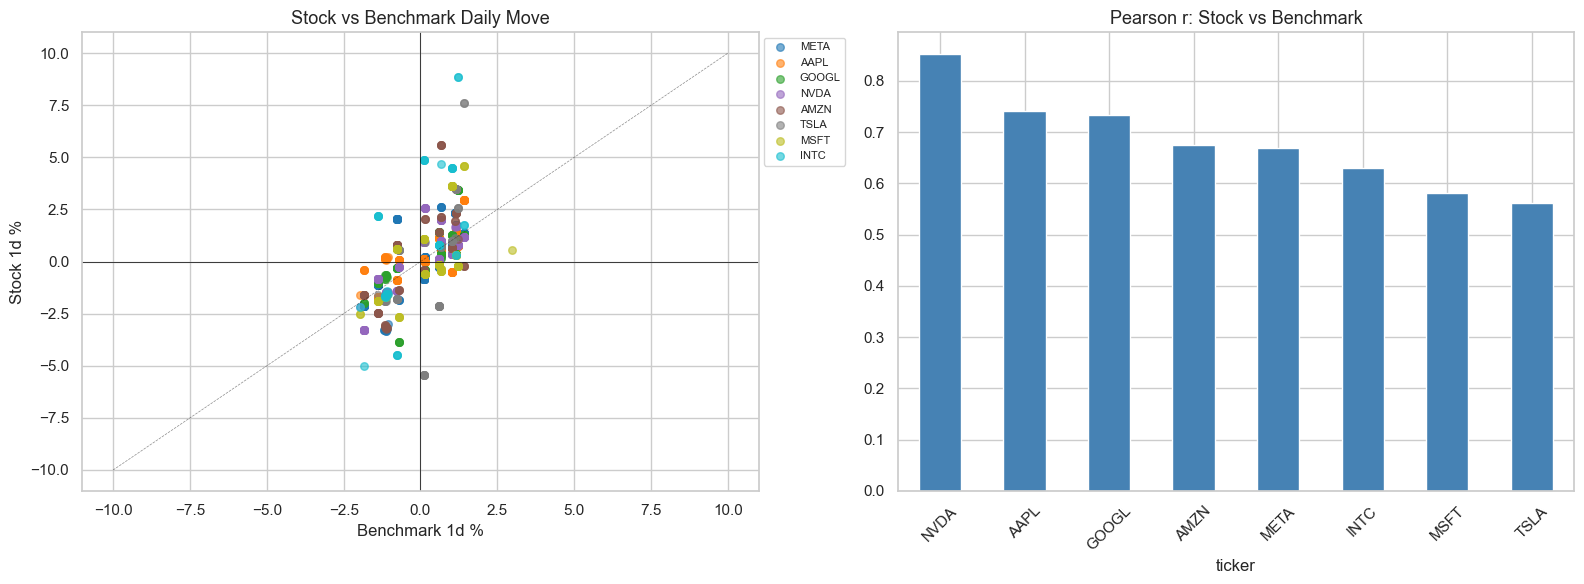


--- Stock vs Benchmark Correlation ---


,benchmark,r,p,n
ticker,,,,
NVDA,QQQ,0.852,0.0,243
AAPL,QQQ,0.741,0.0,191
GOOGL,QQQ,0.733,0.0,103
AMZN,QQQ,0.674,0.0,90
META,QQQ,0.669,0.0,241
INTC,QQQ,0.629,0.0,41
MSFT,QQQ,0.581,0.0,127
TSLA,QQQ,0.561,0.0,62


  Saved: analysis\correlations_stock_vs_benchmark.csv


In [21]:
company_df = df[df['category']=='company'].dropna(subset=['change_1d','bm_change_1d']).copy()
if company_df.empty:
    print('No data yet')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    tickers = company_df['ticker'].unique()
    colors  = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
    for ticker, color in zip(tickers, colors):
        sub = company_df[company_df['ticker']==ticker]
        axes[0].scatter(sub['bm_change_1d'], sub['change_1d'],
                        label=ticker, alpha=0.6, s=30, color=color)
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].plot([-10,10],[-10,10],'k--',linewidth=0.5,alpha=0.5)
    axes[0].set_xlabel('Benchmark 1d %'); axes[0].set_ylabel('Stock 1d %')
    axes[0].set_title('Stock vs Benchmark Daily Move')
    axes[0].legend(bbox_to_anchor=(1,1), fontsize=8)
    corrs = []
    for ticker in tickers:
        sub = company_df[company_df['ticker']==ticker]
        if len(sub) > 5:
            r, p = stats.pearsonr(sub['bm_change_1d'], sub['change_1d'])
            corrs.append({'ticker': ticker, 'benchmark': sub['benchmark'].iloc[0],
                          'r': round(r,3), 'p': round(p,4), 'n': len(sub)})
    corr_df = pd.DataFrame(corrs).set_index('ticker').sort_values('r', ascending=False)
    corr_df['r'].plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Pearson r: Stock vs Benchmark')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
    print('\n--- Stock vs Benchmark Correlation ---')
    display(corr_df)
    save_csv(corr_df, 'correlations_stock_vs_benchmark.csv')

## 7 — Macro Impact on Stocks

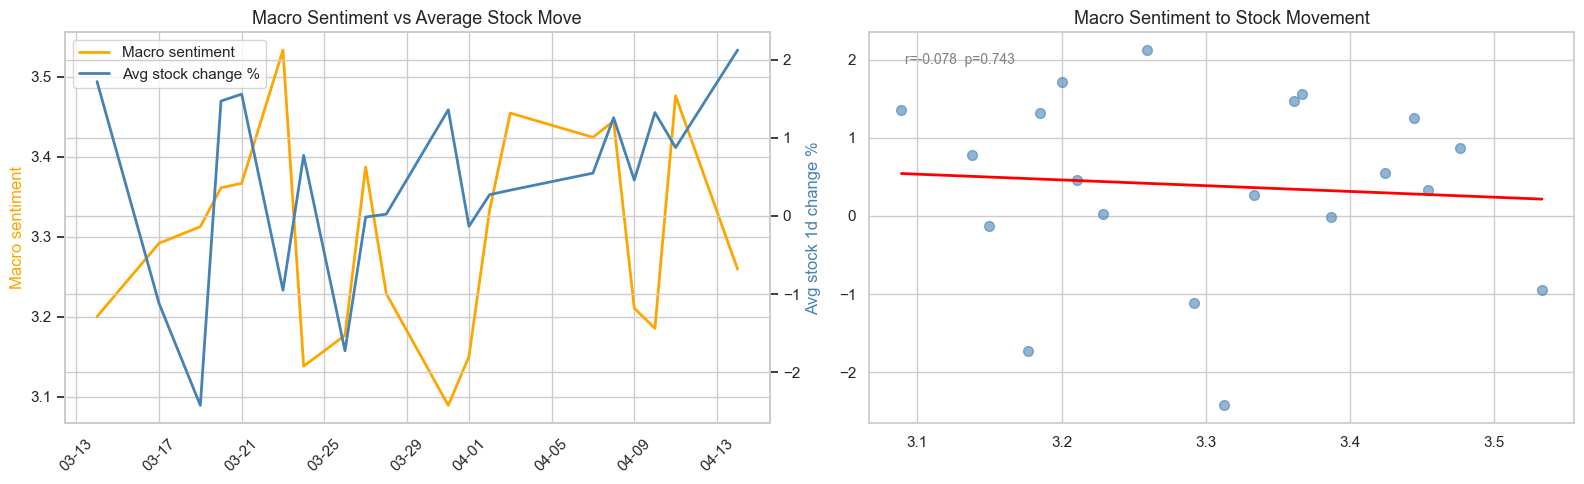


--- Daily Macro Sentiment vs Avg Stock Change ---


,date,macro_sentiment,avg_stock_change,macro_signal
0,2026-03-14,3.2000,1.7207,neutral
1,2026-03-17,3.2917,-1.1193,neutral
2,2026-03-19,3.3125,-2.4264,neutral
3,2026-03-20,3.3611,1.4714,neutral
4,2026-03-21,3.3667,1.5595,neutral
5,2026-03-23,3.5333,-0.9517,neutral
6,2026-03-24,3.1379,0.7761,neutral
7,2026-03-26,3.1765,-1.7273,neutral
8,2026-03-27,3.3871,-0.0146,neutral
9,2026-03-28,3.2286,0.0232,neutral


  Saved: analysis\macro_vs_stocks.csv


In [22]:
macro_df    = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df2 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
if macro_df.empty or company_df2.empty:
    print('Not enough data yet')
else:
    daily_macro  = macro_df.groupby('date')['sentiment'].mean().reset_index()
    daily_macro.columns  = ['date','macro_sentiment']
    daily_stocks = company_df2.groupby('date')['change_1d'].mean().reset_index()
    daily_stocks.columns = ['date','avg_stock_change']
    merged = daily_macro.merge(daily_stocks, on='date')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax2 = axes[0].twinx()
    axes[0].plot(merged['date'], merged['macro_sentiment'], color='orange', linewidth=2, label='Macro sentiment')
    ax2.plot(merged['date'], merged['avg_stock_change'], color='steelblue', linewidth=2, label='Avg stock change %')
    axes[0].set_ylabel('Macro sentiment', color='orange')
    ax2.set_ylabel('Avg stock 1d change %', color='steelblue')
    axes[0].set_title('Macro Sentiment vs Average Stock Move')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    l1,lab1 = axes[0].get_legend_handles_labels()
    l2,lab2 = ax2.get_legend_handles_labels()
    axes[0].legend(l1+l2, lab1+lab2, loc='upper left')
    axes[1].scatter(merged['macro_sentiment'], merged['avg_stock_change'], alpha=0.6, s=50, color='steelblue')
    if len(merged) > 3:
        z = np.polyfit(merged['macro_sentiment'], merged['avg_stock_change'], 1)
        xs = np.linspace(merged['macro_sentiment'].min(), merged['macro_sentiment'].max(), 100)
        axes[1].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
        r, p_val = stats.pearsonr(merged['macro_sentiment'], merged['avg_stock_change'])
        axes[1].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                         xycoords='axes fraction', fontsize=10,
                         color='red' if p_val<0.05 else 'grey')
    axes[1].set_title('Macro Sentiment to Stock Movement')
    plt.tight_layout(); plt.show()

    macro_table = merged.copy()
    macro_table['date'] = macro_table['date'].dt.strftime('%Y-%m-%d')
    macro_table = macro_table.round(4)
    macro_table['macro_signal'] = macro_table['macro_sentiment'].apply(
        lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
    print('\n--- Daily Macro Sentiment vs Avg Stock Change ---')
    display(macro_table)
    save_csv(macro_table.set_index('date'), 'macro_vs_stocks.csv')

## 8 — Sector Sentiment vs Constituent Stock Performance

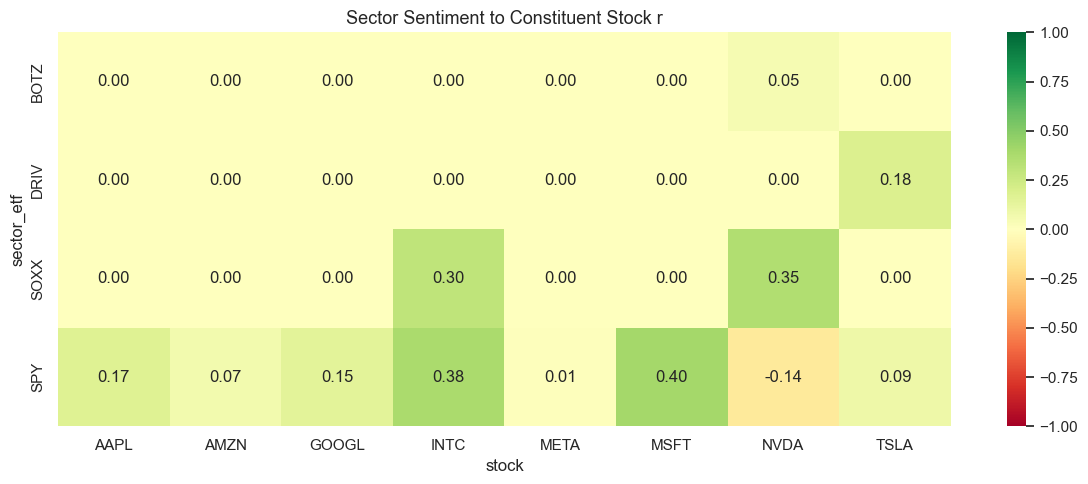


--- Sector Sentiment to Stock Correlation ---


,sector_etf,sector_name,stock,r,p,n_days,significant
6,SPY,S&P500,MSFT,0.400,0.0996,18,No
11,SPY,S&P500,INTC,0.382,0.2207,12,No
0,SOXX,Semiconductor,NVDA,0.352,0.1399,19,No
1,SOXX,Semiconductor,INTC,0.299,0.3457,12,No
3,DRIV,EV,TSLA,0.182,0.4691,18,No
5,SPY,S&P500,AAPL,0.168,0.5058,18,No
10,SPY,S&P500,GOOGL,0.147,0.5742,17,No
8,SPY,S&P500,TSLA,0.086,0.7423,17,No
9,SPY,S&P500,AMZN,0.065,0.7965,18,No
2,BOTZ,AI/Robotics,NVDA,0.048,0.8942,10,No


  Saved: analysis\correlations_sector_vs_stocks.csv


In [23]:
SECTOR_STOCKS = {
    'QQQ':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
    'SOXX': ['NVDA','INTC','AMD'],
    'BOTZ': ['NVDA'],
    'DRIV': ['TSLA'],
    'SPY':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
}
sector_df   = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df3 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
results = []
for sector_ticker, stock_tickers in SECTOR_STOCKS.items():
    sector_news = sector_df[sector_df['ticker']==sector_ticker]
    if sector_news.empty: continue
    daily_sector = sector_news.groupby('date')['sentiment'].mean()
    for stock in stock_tickers:
        stock_prices = company_df3[company_df3['ticker']==stock]
        if stock_prices.empty: continue
        daily_stock = stock_prices.groupby('date')['change_1d'].mean()
        merged = daily_sector.rename('sector_sent').reset_index() \
            .merge(daily_stock.rename('stock_chg').reset_index(), on='date')
        if len(merged) < 5: continue
        r, p_val = stats.pearsonr(merged['sector_sent'], merged['stock_chg'])
        results.append({'sector_etf': sector_ticker,
                        'sector_name': ETF_LABELS.get(sector_ticker, sector_ticker),
                        'stock': stock, 'r': round(r,3), 'p': round(p_val,4),
                        'n_days': len(merged),
                        'significant': 'Yes' if p_val<0.05 else 'No'})
if results:
    res_df  = pd.DataFrame(results)
    pivot_r = res_df.pivot_table(index='sector_etf', columns='stock', values='r', fill_value=0)
    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_r, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
    plt.title('Sector Sentiment to Constituent Stock r')
    plt.tight_layout(); plt.show()
    print('\n--- Sector Sentiment to Stock Correlation ---')
    display(res_df.sort_values('r', ascending=False))
    save_csv(res_df.set_index(['sector_etf','stock']), 'correlations_sector_vs_stocks.csv')
else:
    print('Not enough overlapping dates yet')

## 9 — Dataset Readiness Summary

In [24]:
labeled = df.dropna(subset=['sentiment','bucket_1d'])

ticker_ready = labeled.groupby(['ticker','category']).agg(
    total_articles  = ('url',       'count'),
    unique_days     = ('date',      'nunique'),
    avg_sentiment   = ('sentiment', 'mean'),
    flat_pct        = ('bucket_1d', lambda x: round((x=='flat').mean()*100,1)),
    strong_down_pct = ('bucket_1d', lambda x: round((x=='strong_down').mean()*100,1)),
    strong_up_pct   = ('bucket_1d', lambda x: round((x=='strong_up').mean()*100,1)),
).round(2).reset_index()
ticker_ready['imbalance_flag'] = ticker_ready['flat_pct'].apply(
    lambda x: 'HIGH FLAT' if x>70 else 'OK')
ticker_ready['readiness'] = ticker_ready['total_articles'].apply(
    lambda x: 'LOW <50' if x<50 else ('MED 50-200' if x<200 else 'READY 200+'))

total_examples = int(ticker_ready['total_articles'].sum())
total_ticker_groups = int(ticker_ready[['ticker','category']].drop_duplicates().shape[0])
ready_tickers = int((ticker_ready['readiness'] == 'READY 200+').sum())
medium_tickers = int((ticker_ready['readiness'] == 'MED 50-200').sum())
low_tickers = int((ticker_ready['readiness'] == 'LOW <50').sum())
high_flat_tickers = ticker_ready[ticker_ready['flat_pct'] > 70]['ticker'].unique().tolist()
low_sample_tickers = ticker_ready[ticker_ready['total_articles'] < 50]['ticker'].unique().tolist()
overall_flat_pct = float(bucket_table.loc['flat','pct']) if 'flat' in bucket_table.index else None
neutral_sentiment_pct = float(sent_table.loc[3,'pct']) if 3 in sent_table.index else None
dataset_mismatch_pct = float(mismatch_table['mismatch_pct'].mean()) if 'mismatch_pct' in mismatch_table.columns else None

readiness_flag = (
    total_examples >= 2000 and
    overall_flat_pct is not None and overall_flat_pct <= 50 and
    len(high_flat_tickers) <= 5 and
    len(low_sample_tickers) <= 10 and
    ready_tickers >= 3
)

summary = {
    'total_examples': total_examples,
    'total_ticker_groups': total_ticker_groups,
    'ready_tickers': ready_tickers,
    'medium_tickers': medium_tickers,
    'low_tickers': low_tickers,
    'high_flat_tickers': len(high_flat_tickers),
    'low_sample_tickers': len(low_sample_tickers),
    'overall_flat_pct': overall_flat_pct,
    'neutral_sentiment_pct': neutral_sentiment_pct,
    'dataset_mismatch_pct': dataset_mismatch_pct,
    'ready_to_train': bool(readiness_flag),
    'recommendation': (
        'Proceed with fine-tuning' if readiness_flag else 'Collect more data, reduce flat labels, or improve ticker coverage'
    ),
}

print('='*60)
print('DATASET READINESS SUMMARY')
print('='*60)
print(f'Total articles:    {total_examples:>6,}')
print(f'Total ticker groups: {total_ticker_groups}')
print(f'Ready tickers:      {ready_tickers}')
print(f'Medium tickers:     {medium_tickers}')
print(f'Low sample tickers: {low_tickers}')
print(f'High-flat tickers:  {len(high_flat_tickers)}')
print(f'Overall flat pct:   {overall_flat_pct}')
print(f'Neutral sentiment:  {neutral_sentiment_pct}')
print(f'Average mismatch:   {dataset_mismatch_pct}')
print(f"Ready to train:     {summary['ready_to_train']}")
print()
display(ticker_ready)
save_csv(ticker_ready.set_index('ticker'), 'dataset_readiness.csv')

summary_df = pd.DataFrame([summary])
save_csv(summary_df, 'dataset_readiness_summary.csv')
with open(os.path.join(ANALYSIS_DIR, 'dataset_readiness_metrics.json'), 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2)

print(f"Saved readiness summary to {os.path.join(ANALYSIS_DIR, 'dataset_readiness_summary.csv')}")
print(f"Saved readiness metrics to {os.path.join(ANALYSIS_DIR, 'dataset_readiness_metrics.json')}")


DATASET READINESS SUMMARY
Total articles:     1,732
Total ticker groups: 19
Ready tickers:      3
Medium tickers:     9
Low sample tickers: 7
High-flat tickers:  11
Overall flat pct:   72.3
Neutral sentiment:  38.2
Average mismatch:   8.052631578947368
Ready to train:     False



,ticker,category,total_articles,unique_days,avg_sentiment,flat_pct,strong_down_pct,strong_up_pct,imbalance_flag,readiness
0,AAPL,company,201,20,3.48,88.1,0.0,5.0,HIGH FLAT,READY 200+
1,AMZN,company,93,20,3.66,61.3,0.0,7.5,OK,MED 50-200
2,BOTZ,sector/macro,15,11,2.80,86.7,0.0,13.3,HIGH FLAT,LOW <50
3,DRIV,sector/macro,61,20,3.57,83.6,0.0,4.9,HIGH FLAT,MED 50-200
4,GOOGL,company,112,19,3.33,82.1,0.0,8.0,HIGH FLAT,MED 50-200
5,INTC,company,48,13,3.54,41.7,2.1,18.8,OK,LOW <50
6,META,company,258,20,3.09,63.6,0.0,6.6,OK,READY 200+
7,MSFT,company,137,18,3.28,75.9,0.0,7.3,HIGH FLAT,MED 50-200
8,NVDA,company,251,20,3.47,84.9,0.0,3.2,HIGH FLAT,READY 200+
9,SKYY,sector/macro,8,6,3.12,62.5,0.0,25.0,OK,LOW <50


  Saved: analysis\dataset_readiness.csv
  Saved: analysis\dataset_readiness_summary.csv
Saved readiness summary to analysis\dataset_readiness_summary.csv
Saved readiness metrics to analysis\dataset_readiness_metrics.json
